In [7]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from typing import Callable, Optional
from utils.algorithms import RGD, PerfGD
from utils.experiment_setup import setup_1d_non_linear_experiment
from poisoning.oracle import oracle_poison_function, RGD_update_estimator, PerfGD_update_estimator
from utils.plotting import plot_results_1d

# Non-linear means

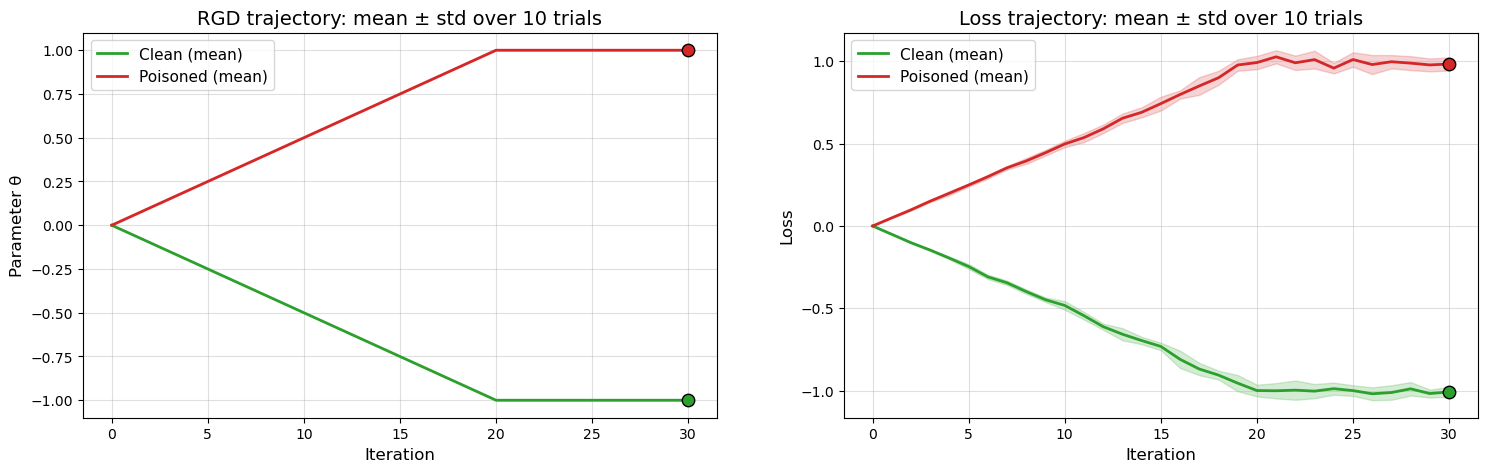

In [26]:
n_trials = 10

a0 = 0.0
a1 = 1.0

proj_theta = lambda theta: torch.clamp(theta, min=-1.0, max=1.0)

n = 500
eta = 0.05
max_iter = 30

poison_steps = 10
poison_step_size = 0.5
epsilon = 0.7
delta = 5

mu, D_theta, loss, theta_0, info = setup_1d_non_linear_experiment(a0=a0, a1=a1)

def run_trial():
    theta_star_clean, all_theta_clean, all_losses_clean = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                return_losses=True
    )

    theta_star_poisoned, all_theta_poisoned, all_losses_poisoned = RGD(
                D_theta=D_theta,
                loss=loss,
                theta_0=theta_0.clone(),
                proj_theta=proj_theta,
                n=n,
                eta=eta,
                max_iter=max_iter,
                return_losses=True,
                poison_function=oracle_poison_function,
                theta_update_estimator=RGD_update_estimator,
                poison_steps=poison_steps,
                poison_step_size=poison_step_size,
                epsilon=epsilon,
                delta=delta,
                mu=mu,
                sigma=torch.tensor([[1.0]]),
    )

    return all_theta_clean, all_theta_poisoned, all_losses_clean, all_losses_poisoned

all_theta_clean_list = []
all_theta_poisoned_list = []
all_loss_clean_list = []
all_loss_poisoned_list = []

for trial in range(n_trials):
    all_theta_clean, all_theta_poisoned, all_loss_clean, all_loss_poisoned = run_trial()
    all_theta_clean_list.append(all_theta_clean) 
    all_theta_poisoned_list.append(all_theta_poisoned)
    all_loss_clean_list.append(all_loss_clean)
    all_loss_poisoned_list.append(all_loss_poisoned)

fig, (ax1, ax2) = plot_results_1d(all_theta_clean_list, 
                    all_theta_poisoned_list,
                    all_loss_clean_list, 
                    all_loss_poisoned_list
                    )

plt.show()